In [ ]:
# BÀI TOÁN HỒI QUY
# Dự đoán mức tiêu thụ nhiên liệu tổng hợp của xe

 kết nối

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

**3. Đọc dữ liệu**

In [ ]:
df = pd.read_csv('drive/MyDrive/Colab Notebooks/BTL_hocmay/fuel.csv')

/tmp/ipykernel_8017/2129353085.py:1: DtypeWarning: Columns (7,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('drive/MyDrive/Colab Notebooks/BTL_hocmay/fuel.csv')


In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
print(df.head())

   vehicle_id  year        make               model  \
0       26587  1984  Alfa Romeo           GT V6 2.5   
1       27705  1984  Alfa Romeo           GT V6 2.5   
2       26561  1984  Alfa Romeo  Spider Veloce 2000   
3       27681  1984  Alfa Romeo  Spider Veloce 2000   
4       27550  1984  AM General   DJ Po Vehicle 2WD   

                         class          drive       transmission  \
0             Minicompact Cars            NaN     Manual 5-Speed   
1             Minicompact Cars            NaN     Manual 5-Speed   
2                  Two Seaters            NaN     Manual 5-Speed   
3                  Two Seaters            NaN     Manual 5-Speed   
4  Special Purpose Vehicle 2WD  2-Wheel Drive  Automatic 3-Speed   

  transmission_type  engine_index engine_descriptor  ...  \
0               NaN          9001             (FFS)  ...   
1               NaN          9005    (FFS) CA model  ...   
2               NaN          9002             (FFS)  ...   
3               NaN 

In [ ]:
#display(df.tail())
#df.info()
#df.describe()

chọn biến đầu vào và biến mục tiêu

In [ ]:
# mức tiêu thụ nhiên liệu tổng hợp MPG của xe
target = "combined_mpg_ft1" # giá trị cần dự đoán
#các thuộc tính được chọn
features = [
    "year",
    "make",
    "class",
    "drive",
    "transmission",
    "engine_cylinders",
    "engine_displacement",
    "fuel_type_1"
]

data = df[features + [target]].copy()


In [ ]:
#Những dòng không có giá trị MPG tổng hợp sẽ bị loại bỏ vì không có nhãn để mô hình học
data = data.dropna(subset=[target])

In [ ]:
data.isna().sum() #kiểm tra giá trị thiếu

,0
year,0
make,0
class,0
drive,1189
transmission,11
engine_cylinders,136
engine_displacement,134
fuel_type_1,0
combined_mpg_ft1,0


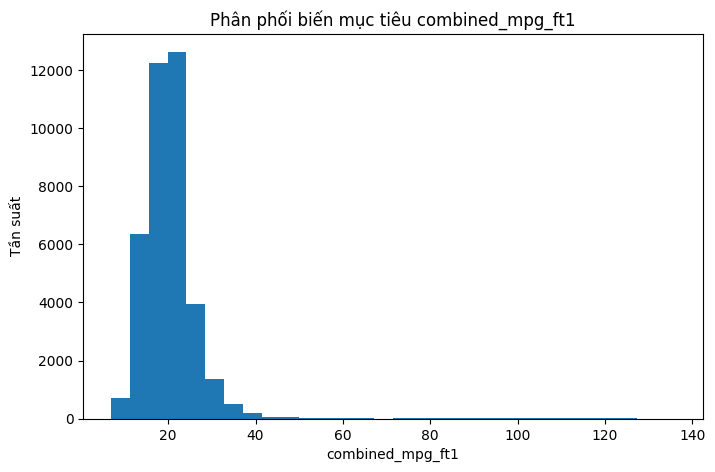

In [ ]:
# EDA phân phối biến mục tiêu

plt.figure(figsize=(8, 5))
plt.hist(data[target], bins=30)
plt.xlabel("combined_mpg_ft1")
plt.ylabel("Tần suất")
plt.title("Phân phối biến mục tiêu combined_mpg_ft1")
plt.show()


Biểu đồ phân phối biến mục tiêu combined_mpg_ft1 cho thấy phần lớn các mẫu xe có mức MPG tổng hợp tập trung trong khoảng 15–25. Phân phối có dạng lệch phải, với một số giá trị MPG rất cao xuất hiện ít hơn. Điều này cho thấy dữ liệu tồn tại các trường hợp đặc biệt hoặc ngoại lệ, có thể ảnh hưởng đến quá trình huấn luyện mô hình hồi quy.

In [ ]:
X = data[features] # tách x y (x dl đầu vào, y gtri cần dự đoán)
y = data[target]

**Chia nhóm biến số và biến phân loại**

In [ ]:
# biến số
numeric_features = [
    "year",
    "engine_cylinders",
    "engine_displacement"
]

In [ ]:
# biến phân loại
categorical_features = [
    "make",
    "class",
    "drive",
    "transmission",
    "fuel_type_1"
]

**Tiền xử lý biến số**

- Điền giá trị thiếu bằng median
- Chuẩn hóa bằng StandardScaler


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #Điền giá trị thiếu bằng trung vị (Median ít bị ảnh hưởng bởi giá trị ngoại lệ hơn mean.)
    ("scaler", StandardScaler()) #chuẩn hóa (Giúp các biến số có cùng thang đo)
])

**Tiền xử lý biến phân loại**

- Điền giá trị thiếu bằng giá trị xuất hiện nhiều nhất
- Mã hóa One-Hot Encoding

In [ ]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), #Điền giá trị thiếu bằng giá trị xuất hiện nhiều nhất
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
# ghép bước tiền xử lý

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

ColumnTransformer giúp áp dụng cách xử lý khác nhau cho từng nhóm cột.

Cột số thì điền thiếu + chuẩn hóa.

Cột phân loại thì điền thiếu + One-Hot Encoding.

**Chia train/test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Đưa tiền xử lí vào mô hình**

không nên xử lý dữ liệu thủ công rời rạc. Nên đưa vào Pipeline để tránh lỗi và tránh rò rỉ dữ liệu.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'engine_cylinders',
                                                   'engine_displacement']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['make', 'class', 'drive',
                                                   'transmission',
                                                   'fuel_type_1'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

**Nhận xét **

Trong giai đoạn tiền xử lý dữ liệu, tiến hành lựa chọn các thuộc tính đầu vào phù hợp gồm năm sản xuất, hãng xe, loại xe, hệ dẫn động, hộp số, số xi lanh, dung tích động cơ và loại nhiên liệu. Biến mục tiêu của bài toán là combined_mpg_ft1, thể hiện mức tiêu thụ nhiên liệu tổng hợp của xe.

Các dòng bị thiếu giá trị ở biến mục tiêu được loại bỏ vì không thể sử dụng để huấn luyện mô hình. Sau đó, dữ liệu được tách thành biến đầu vào X và biến mục tiêu y.

Đối với các biến số như year, engine_cylinders và engine_displacement,sử dụng phương pháp điền giá trị thiếu bằng trung vị và chuẩn hóa bằng StandardScaler. Đối với các biến phân loại như make, class, drive, transmission và fuel_type_1, điền giá trị thiếu bằng giá trị xuất hiện nhiều nhất và mã hóa bằng OneHotEncoder.

Toàn bộ quá trình tiền xử lý được tích hợp vào Pipeline và ColumnTransformer nhằm đảm bảo dữ liệu huấn luyện và dữ liệu kiểm tra được xử lý nhất quán, đồng thời hạn chế hiện tượng rò rỉ dữ liệu.

**Linear Regression**

In [ ]:
# Tạo pipeline gồm tiền xử lý + mô hình hồi quy tuyến tính
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [ ]:
# Huấn luyện mô hình
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'engine_cylinders',
                                                   'engine_displacement']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['make', 'class', 'drive',
                                                   'transmission',
                                                   'fuel_type_1'])])),
                ('model', LinearRegression())])

In [ ]:
# Dự đoán
y_pred_linear = linear_model.predict(X_test)

In [ ]:
# Đánh giá
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("===== Linear Regression =====")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R2:", r2_linear)

===== Linear Regression =====
MAE: 1.556268556737635
RMSE: 2.544708725381966
R2: 0.8563217765107399


**Mô hình Random Forest Regressor**

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42
    ))
])


In [ ]:
rf_model.fit(X_train, y_train) # huấn luyện

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'engine_cylinders',
                                                   'engine_displacement']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['make', 'class', 'drive',
                                                   'transmission',
                                                   'fuel_type_1'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, random_state=42))])

In [ ]:

y_pred_rf = rf_model.predict(X_test) #dự đoán

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("===== Random Forest Regressor =====")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

===== Random Forest Regressor =====
MAE: 0.7048020751812598
RMSE: 1.2431407753727832
R2: 0.965710952990796


Random Forest tốt hơn Linear Regression vì MAE và RMSE thấp hơn, còn R2 cao hơn. Mô hình này học được các quan hệ phi tuyến giữa thông tin xe và MPG.

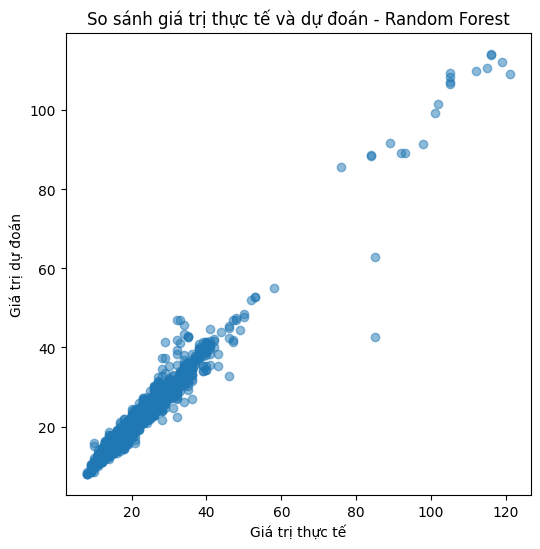

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Giá trị thực tế")
plt.ylabel("Giá trị dự đoán")
plt.title("So sánh giá trị thực tế và dự đoán - Random Forest")
plt.show()

**Nhận xét biểu đồ**

Biểu đồ so sánh giá trị thực tế và giá trị dự đoán cho thấy mô hình Random Forest có khả năng dự đoán tốt khi phần lớn các điểm dữ liệu nằm gần đường chéo. Điều này phù hợp với kết quả đánh giá định lượng khi mô hình đạt R2 cao và RMSE thấp. Tuy nhiên, ở một số mẫu có giá trị MPG rất cao, mô hình vẫn xuất hiện sai số lớn, cho thấy khả năng dự đoán đối với các trường hợp ngoại lệ còn hạn chế.

In [ ]:
#so sánh 2 mô hình
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_rf
    ]
})

results = results.sort_values(by="RMSE")

print("===== So sánh mô hình =====")
print(results)

===== So sánh mô hình =====
               Model       MAE      RMSE        R2
1      Random Forest  0.704802  1.243141  0.965711
0  Linear Regression  1.556269  2.544709  0.856322


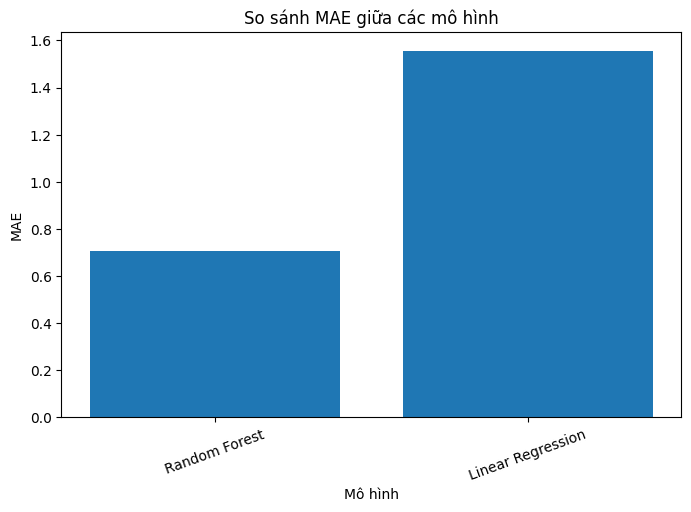

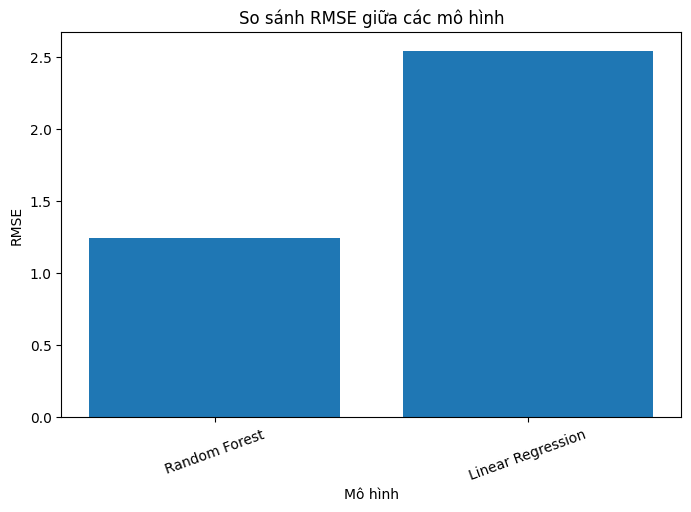

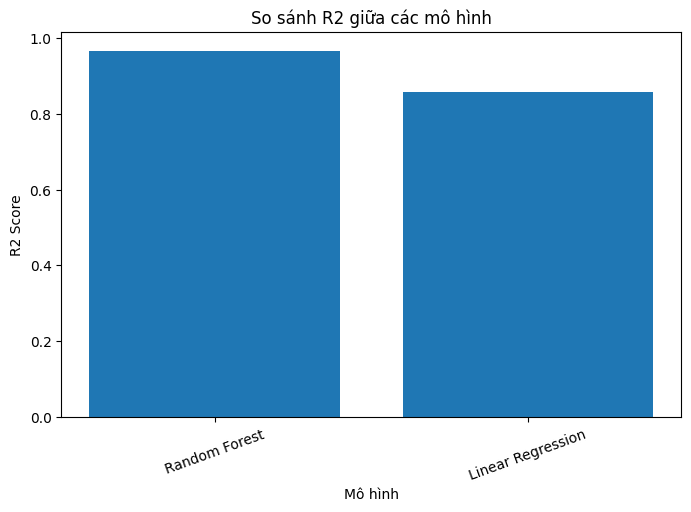

In [ ]:
import matplotlib.pyplot as plt

# Trực quan hóa so sánh MAE
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["MAE"])
plt.xlabel("Mô hình")
plt.ylabel("MAE")
plt.title("So sánh MAE giữa các mô hình")
plt.xticks(rotation=20)
plt.show()

# Trực quan hóa so sánh RMSE
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["RMSE"])
plt.xlabel("Mô hình")
plt.ylabel("RMSE")
plt.title("So sánh RMSE giữa các mô hình")
plt.xticks(rotation=20)
plt.show()

# Trực quan hóa so sánh R2
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["R2"])
plt.xlabel("Mô hình")
plt.ylabel("R2 Score")
plt.title("So sánh R2 giữa các mô hình")
plt.xticks(rotation=20)
plt.show()

Các biểu đồ so sánh MAE, RMSE và R2 cho thấy Random Forest có sai số thấp hơn Linear Regression và đạt hệ số R2 cao hơn. Điều này chứng tỏ Random Forest phù hợp hơn với bài toán hồi quy này.

In [ ]:
#kiểm tra overfit
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

train_r2 = r2_score(y_train, y_train_pred_rf)
test_r2 = r2_score(y_test, y_test_pred_rf)

print("===== Kiểm tra Overfitting - Random Forest =====")
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

===== Kiểm tra Overfitting - Random Forest =====
Train RMSE: 0.7886861655364182
Test RMSE: 1.2431407753727832
Train R2: 0.9864966973242638
Test R2: 0.965710952990796


Nhận xét

Mô hình ovf nhẹ vì mô hình dự đoán trên tập train tốt hơn tập test: Train RMSE < Test RMSE và Train R2 > Test R2

điều này cho thấy Random Forest học dữ liệu train rất tốt, còn khi gặp dữ liệu test thì sai số tăng lên.

